In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working!")

Everything is working!


In [ ]:
df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

## data cleaning

In [18]:
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
df_clean.shape

(10000, 11)

## exploratory data analysis

In [ ]:
# calculate the churn rate for each country
churn_by_geography = df_clean.groupby("Geography")["Exited"].mean() * 100

# display churn
churn_by_geography

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

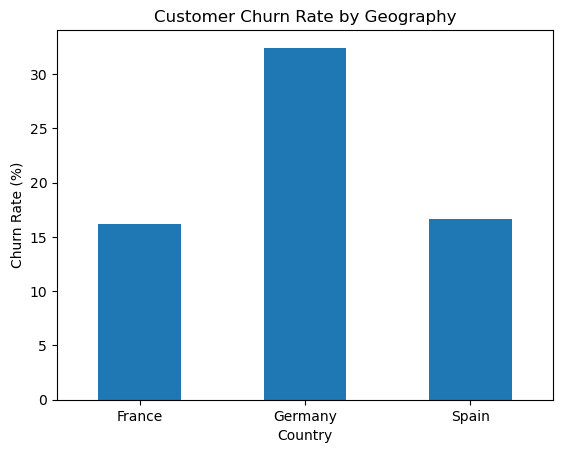

In [21]:
# create a bar chart 
churn_by_geography.plot(kind="bar")

# titles
plt.title("Customer Churn Rate by Geography")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

# display chart
plt.show()

## insight 1, geography: German customers churn at roughly twice the rate observed in the other two markets. This suggests geography may be associated with customer churn.

In [22]:
# calculate the churn rate for each gender
churn_by_gender = df_clean.groupby("Gender")["Exited"].mean() * 100

# display churn 
churn_by_gender

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

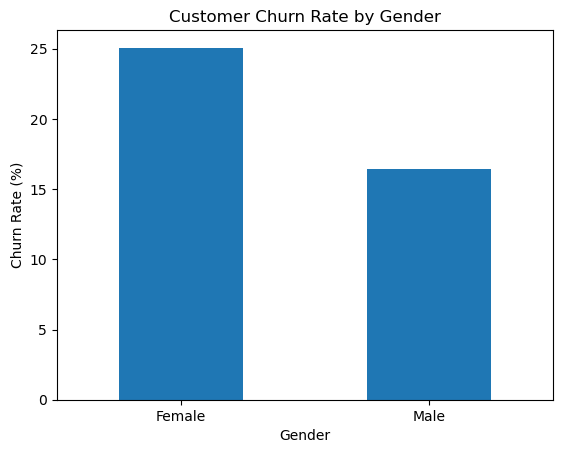

In [23]:
# create bar chart
churn_by_gender.plot(kind="bar")

# titles
plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

# display 
plt.show()

## insight 2, gender: fenale customers have an almost 9% higher churn rate compared to their male counterparts. This could suggest that gender is associated with churn, although further analysis is needed to determine if other characteristics influence this.

In [24]:
# Calculate the average age for customers who stayed vs. churned
age_by_churn = df_clean.groupby("Exited")["Age"].mean()

# Display the average ages
age_by_churn

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [25]:
# create age groups to compare churn across different customer ages
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

# calculate the churn rate for each age group
churn_by_age = df_clean.groupby(
    "AgeGroup", observed=True
)["Exited"].mean() * 100

# Display 
churn_by_age

AgeGroup
18-30     7.520325
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: Exited, dtype: float64

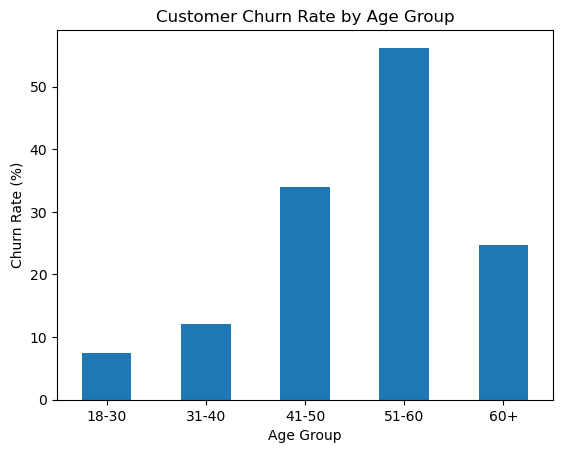

In [26]:
# create bar chart 
churn_by_age.plot(kind="bar")

# Add titles
plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

# display 
plt.show()

## insight 3, age group: Churn tends to increase with age, with customers aged 51–60 having the highest churn rate at 56.2%. Customers aged 41–50 also have a higher churn rate of 34.0%, while it drops to 24.8% for those over 60. This suggests that customers aged 51–60 are the highest-risk group.

In [27]:
# calculate churn rate for active and inactive customers
churn_by_activity = df_clean.groupby("IsActiveMember")["Exited"].mean() * 100

# rename the categories 
churn_by_activity.index = ["Inactive", "Active"]

# display 
churn_by_activity

Inactive    26.850897
Active      14.269074
Name: Exited, dtype: float64

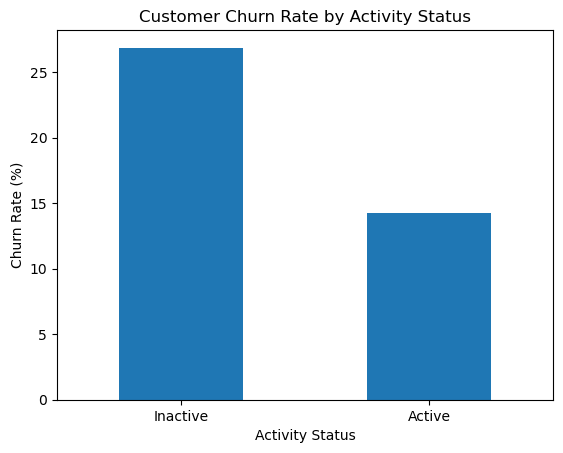

In [28]:
# Create bar chart 
churn_by_activity.plot(kind="bar")

# titles
plt.title("Customer Churn Rate by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

# display
plt.show()

## insight 4, activity status: With inactive customers having a 12.6% higher churn rate, this suggests that lower customer engagement is associated with higher risk of churn. Increasing engagement among inactive customers may therefore represent an opportunity to reduce churn.

In [29]:
# Calculate churn rate based on the number of products a customer has
churn_by_products = df_clean.groupby("NumOfProducts")["Exited"].mean() * 100

# Count customers in each product group 
customers_by_products = df_clean["NumOfProducts"].value_counts().sort_index()

# Display churn rate and customer count together
product_analysis = pd.DataFrame({
    "Customer Count": customers_by_products,
    "Churn Rate (%)": churn_by_products
})

product_analysis

,Customer Count,Churn Rate (%)
NumOfProducts,,
1,5084,27.714398
2,4590,7.581699
3,266,82.706767
4,60,100.000000


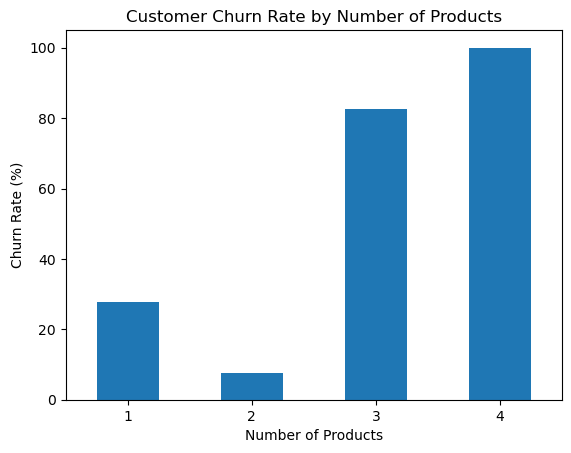

In [30]:
# Create bar chart
churn_by_products.plot(kind="bar")

# titles
plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

# display
plt.show()

## insight 5, number of products and churn: Customers with two products have the lowest churn rate at approximately 7.6%, compared with 27.7% for customers with one product. Churn is much higher among customers with three or four products, although these groups contain far fewer customers and should therefore be interpreted cautiously.

In [31]:
# Compare average financial/customer characteristics for customers who stayed vs. churned
remaining_analysis = df_clean.groupby("Exited")[
    ["Balance", "CreditScore", "Tenure"]
].mean()

remaining_analysis.index = ["Stayed", "Churned"]

# display
remaining_analysis.round(2)

,Balance,CreditScore,Tenure
Stayed,72745.30,651.85,5.03
Churned,91108.54,645.35,4.93


## insight 6, financial situation: Customers who churned had a higher average balance ($91,109) than customers who stayed ($72,745). Credit score and tenure were very similar between the two groups, suggesting they may have less of a relationship with churn.

## churn prediction model: A logistic regression model will be used to predict whether a customer is likely to churn based on their demographic, financial, and account characteristics.

In [ ]:
X = df_clean.drop(columns=["Exited", "AgeGroup"])
y = df_clean["Exited"]

# Check which features will be used to predict churn
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [34]:
# Convert categorical columns into numerical dummy variables
X_encoded = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

# Preview the model-ready data
X_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
# Import the tool used to split our dataset
from sklearn.model_selection import train_test_split

# Split the data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2, # reserve 20% for testing
    random_state=42,# making split reproducible
    stratify=y #keep same proportion of churned and non-churned cust. in training and testing datasets
)

# Check the size of each dataset
print("Training customers:", X_train.shape[0])
print("Testing customers:", X_test.shape[0])

Training customers: 8000
Testing customers: 2000


In [37]:
# Import StandardScaler to put numerical features on a similar scale
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler using ONLY the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train) # the scaler learns things

# Use the same scaling learned from the training data on the test data
X_test_scaled = scaler.transform(X_test) # the scaler uses what it has learned to scale the testing dataset

# Check the dimensions to make sure nothing was lost
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8000, 11)
Testing data shape: (2000, 11)


In [38]:
# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(random_state=42)

# Train the model using the training data
logistic_model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


In [39]:
# Use the trained model to predict churn for the test customers
y_pred = logistic_model.predict(X_test_scaled)

# Look at the first 20 predictions
# 0 = predicted to stay, 1 = predicted to churn
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [40]:
# Import metrics used to evaluate how well the model predicts churn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compare the model's predictions with what actually happened
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the model's performance as percentages
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")

Accuracy:  80.80%
Precision: 58.91%
Recall:    18.67%
F1 Score:  28.36%


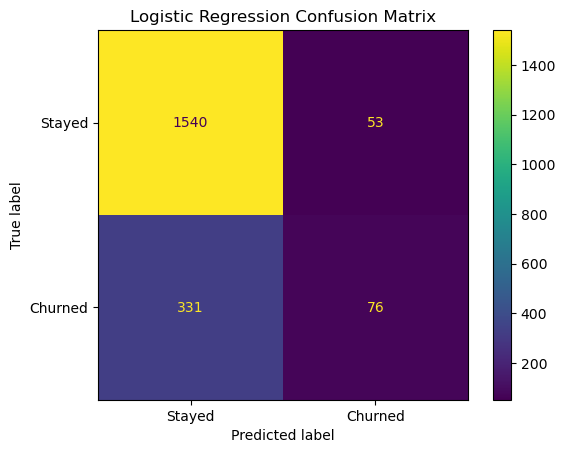

In [53]:
# Import the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compare actual customer outcomes with the model's predictions
cm = confusion_matrix(y_test, y_pred)

# Display the results visually
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## improving churn detection

In [42]:
# Create a second logistic regression model that gives more importance to the smaller churned customer group
balanced_model = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

# Train the improved model using the same training data
balanced_model.fit(X_train_scaled, y_train)

# Predict churn for the same testing customers
y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Balanced model training complete!")

Balanced model training complete!


In [43]:
# Calculate performance metrics for the balanced model
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

# Compare the original model with the balanced model
print("ORIGINAL MODEL")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")

print("\nBALANCED MODEL")
print(f"Accuracy:  {balanced_accuracy:.2%}")
print(f"Precision: {balanced_precision:.2%}")
print(f"Recall:    {balanced_recall:.2%}")
print(f"F1 Score:  {balanced_f1:.2%}")

ORIGINAL MODEL
Accuracy:  80.80%
Precision: 58.91%
Recall:    18.67%
F1 Score:  28.36%

BALANCED MODEL
Accuracy:  71.35%
Precision: 38.72%
Recall:    70.02%
F1 Score:  49.87%


## model comparison: Balancing the model lowered the overall accuracy from 80.8% to 71.4%, but made it much better at identifying customers who actually churned. Recall increased from 18.7% to 70.0%, and the F1 score improved from 28.4% to 49.9%.
For customer retention, the balanced model is more useful because it catches more customers who may be at risk of leaving, even though it also creates more false positives.

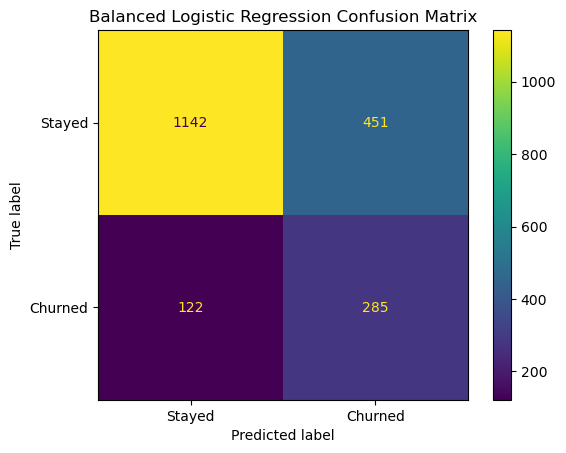

In [52]:
# Create a confusion matrix for the balanced model
balanced_cm = confusion_matrix(y_test, y_pred_balanced)

# Display the balanced model's predictions
balanced_disp = ConfusionMatrixDisplay(
    confusion_matrix=balanced_cm,
    display_labels=["Stayed", "Churned"]
)

balanced_disp.plot()
plt.title("Balanced Logistic Regression Confusion Matrix")
# Save the confusion matrix for the project README
plt.savefig(
    "../images/balanced_confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

In [45]:
# Get the coefficient assigned to each customer characteristic
feature_effects = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": balanced_model.coef_[0]
})

# Sort from the strongest positive effect to strongest negative effect
feature_effects = feature_effects.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the results
feature_effects

,Feature,Coefficient
1,Age,0.801883
8,Geography_Germany,0.357669
3,Balance,0.175751
7,EstimatedSalary,0.050502
9,Geography_Spain,0.023974
2,Tenure,-0.018831
5,HasCrCard,-0.031611
4,NumOfProducts,-0.057734
0,CreditScore,-0.087119
10,Gender_Male,-0.272170


## Model insight: Age had the strongest positive relationship with predicted churn, followed by being located in Germany and having a higher balance. Active membership had the strongest negative relationship with predicted churn. These results are generally consistent with the patterns found during exploratory analysis. The coefficients represent associations used by the model and should not be interpreted as causal effects.

In [46]:
# Predict each test customer's probability of churning
# [:, 1] selects the probability for class 1 = "Churned"
churn_probability = balanced_model.predict_proba(X_test_scaled)[:, 1]

# Create a table containing the actual outcome, prediction, and churn probability
prediction_results = X_test.copy()

prediction_results["Actual_Churn"] = y_test.values
prediction_results["Predicted_Churn"] = y_pred_balanced
prediction_results["Churn_Probability"] = churn_probability

# Display the first 10 customers
prediction_results.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Actual_Churn,Predicted_Churn,Churn_Probability
5702,585,36,7,0.00,2,1,0,94283.09,0,0,1,0,0,0.317424
3667,525,33,4,131023.76,2,0,0,55072.93,1,0,1,0,1,0.576747
1617,557,40,4,0.00,2,0,1,105433.53,0,1,0,0,0,0.349834
5673,639,34,5,139393.19,2,0,0,33950.08,0,1,1,0,0,0.380206
4272,640,34,3,77826.80,1,1,1,168544.85,0,1,0,0,0,0.301455
8270,559,34,0,0.00,1,1,0,182988.94,0,1,1,0,0,0.350624
7079,595,30,9,130682.11,2,1,1,57862.88,1,0,1,0,0,0.275261
5295,706,29,6,185544.36,1,1,0,171037.63,1,0,0,0,1,0.659486
845,505,49,7,80001.23,1,0,0,135180.11,0,0,1,0,1,0.674234
5311,714,40,0,0.00,2,1,0,62762.12,0,0,0,0,0,0.496845


In [47]:
balanced_model.predict_proba(X_test_scaled)

array([[0.68257578, 0.31742422],
       [0.42325348, 0.57674652],
       [0.65016594, 0.34983406],
       ...,
       [0.11171861, 0.88828139],
       [0.65276929, 0.34723071],
       [0.64606499, 0.35393501]], shape=(2000, 2))

In [48]:
# Create risk categories based on each customer's predicted churn probability
prediction_results["Risk_Level"] = pd.cut(
    prediction_results["Churn_Probability"],
    bins=[0, 0.4, 0.6, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

# Count how many test customers fall into each risk category
prediction_results["Risk_Level"].value_counts()

Risk_Level
Low Risk       952
Medium Risk    559
High Risk      489
Name: count, dtype: int64

In [49]:
# Convert churn probability from a decimal to a percentage
prediction_results["Churn_Probability_Percent"] = (
    prediction_results["Churn_Probability"] * 100
).round(2)

# Replace 0/1 predictions with readable labels
prediction_results["Actual_Churn_Label"] = prediction_results[
    "Actual_Churn"
].map({0: "Stayed", 1: "Churned"})

prediction_results["Predicted_Churn_Label"] = prediction_results[
    "Predicted_Churn"
].map({0: "Stayed", 1: "Churned"})

# Preview the final dataset before exporting
prediction_results.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level,Churn_Probability_Percent,Actual_Churn_Label,Predicted_Churn_Label
5702,585,36,7,0.00,2,1,0,94283.09,0,0,1,0,0,0.317424,Low Risk,31.74,Stayed,Stayed
3667,525,33,4,131023.76,2,0,0,55072.93,1,0,1,0,1,0.576747,Medium Risk,57.67,Stayed,Churned
1617,557,40,4,0.00,2,0,1,105433.53,0,1,0,0,0,0.349834,Low Risk,34.98,Stayed,Stayed
5673,639,34,5,139393.19,2,0,0,33950.08,0,1,1,0,0,0.380206,Low Risk,38.02,Stayed,Stayed
4272,640,34,3,77826.80,1,1,1,168544.85,0,1,0,0,0,0.301455,Low Risk,30.15,Stayed,Stayed


In [50]:
# Export model results for use in the Power BI dashboard
prediction_results.to_csv(
    "../data/churn_predictions.csv",
    index=False
)

print("Prediction data exported successfully!")

Prediction data exported successfully!


## Model Summary

The original logistic regression model achieved 80.8% accuracy, but identified only 18.7% of customers who actually churned. This made accuracy somewhat misleading because most customers in the dataset did not churn.

After accounting for the class imbalance, the balanced model identified 70.0% of customers who churned and improved the F1 score from 28.4% to 49.9%, although overall accuracy decreased to 71.4%.

For a customer retention use case, the balanced model is more useful because identifying customers at risk of leaving is more important than maximizing overall accuracy.

The model also supported several patterns found during exploratory analysis. Age and being located in Germany were associated with a higher likelihood of churn, while active membership was associated with a lower likelihood of churn.

The final model was used to assign churn probabilities and Low, Medium, or High risk levels to customers for use in the Power BI dashboard.